Simple fusion reactor systems code, based on the approach in Plasma Physics and Fusion Energy, Freidberg  
Section 5.5  
Adapted and expanded by Richard Kembleton for TU/e Fusion Reactor Design Masterclass  
2021  
Additional plasma equations from Iter Physics Design Guidelines 1989 (Uckan)  
and Iter Physics Basis Nucl. Fusion 39 (1999)  
Radiation equations from  
Matthews et al, Nuc. Fus. 39 (1999)  
Johner, Fus. Sci. Tech. 59 (2011)  
Uckan (1989)  

In [1]:
from IPython import embed
from simplesystemcode import InputParameters, simplesystemcode
from utilities import plot_scan, write_csv

In [2]:

# Assumed inputs/targets: have a play! 
input_parameters = InputParameters(
	GrossElecPower=1000.0,
	WallLoad=4.0,
	BMax=13.0,
	SigmaMax=300.0,
	Li6=0.075,
	NeutShield=0.99,
	BlktSupport=0.3,
	ThermalEff=0.4,
	Kappa=1.0,
	PlasmaT=15.0,
	SafetyFac=3.5,
	GamCD=0.5,
	ElectEffCD=0.5,
	PowerRecirc=0.05,
	ZEff=1.0
)


In [ ]:
# # EU DEMO
# input_parameters = InputParameters(
# 	GrossElecPower=500.0,
#     # Neutron wall load in MW/m^2
# 	WallLoad=1.0,
#     # Maximum magnetic field on the TF superconductor in Tesla
# 	BMax=12.0,
#     # Maximum stress on the TF structure in MPa
# 	SigmaMax=300.0,
# 	# Fractional concentration of Li6 in breeder material (7.5% in natural lithium)
# 	Li6=0.075,
# 	# Neutron shielding efficiency target for blanket and vacuum vessel
# 	NeutShield=0.99,
# 	# Blanket/shield structural support thickness in meters
# 	BlktSupport=0.3,
# 	# Thermal efficiency of electricity generation (Pe/Pth)
# 	ThermalEff=0.4,
# 	# Plasma elongation
# 	Kappa=1.0,
# 	# Plasma temperature in keV
# 	PlasmaT=15.0,
# 	# Plasma safety factor (q_edge)
# 	SafetyFac=3.5,
# 	# Current drive efficiency (gamma_CD)
# 	GamCD=0.5,
# 	# Electrical efficiency of the CD system
# 	ElectEffCD=0.5,
# 	# Fraction of extracted heat representing coolant pumping power.
# 	PowerRecirc=0.05,
# 	# Plasma effective charge number
# 	ZEff=1.05
# )

In [4]:

## Do a single run of the systems code
design_point = simplesystemcode(input_parameters)


Simple systems code fusion power plant:

Major radius: 2.37 m
Minor radius: 2.11 m
Aspect ratio: 1.12
Plasma elongation: 1.00
Stable elongation: 5.64
Bootstrap current fraction: 0.00
Plasma volume: 208.56 m3
Plasma surface area: 197.39 m2

Fusion power: 980.00 MW
CD power for steady-state: -1827.52 MW
CD electrical power: -3655.04 MW
Coolant pumping power: 62.50 MW
Net elec power: 4092.54 MW

H factor: nan (IPB98(y,2))
n / nG: -0.16
Divertor power loading: nan MW T m-1
Field in plasma: -4.76 T
Normalised beta: 0.61 % m T MA-1
Line radiation: 0.00 MW
Bremsstrahlung radiation: 19.01 MW
Synchrotron radiation: nan MW
Plasma ZEff: 1.00

Magnet thickness: 0.70 m
Blanket/shield thickness: 1.19 m
Bore: -1.64 m
Wall load: 3.97 MW m-2


/home/IPP-HGW/jedwal/small_projects/simple-fusion-systems-code-main/simplesystemcode.py:100: RuntimeWarning: invalid value encountered in scalar power
  PTauE = 0.0562 * PlasCur**0.93 * MagField**0.15 * (10.0*PlasmaDens)**0.41 * PlasHeat**(-0.69) * RMajor**1.97 * inputs.Kappa**0.78 * InvAspect**0.58 * 2.5**0.19 # Prediction from IPB98(y,2), s
/home/IPP-HGW/jedwal/small_projects/simple-fusion-systems-code-main/simplesystemcode.py:120: RuntimeWarning: invalid value encountered in scalar power
  Lambda0 = 77.7 * ((PlasmaDens * RMinor)/MagField)**0.5 # Lambda factor for synchrotron radiation


In [5]:

## sample code for elongation scan
elongations = [1.0,1.1,1.2,1.3,1.4,1.5,1.6]
scan_out = []

for elongation in elongations:
	input_parameters.Kappa = elongation
	scan_out.append(simplesystemcode(input_parameters, print_out=False))


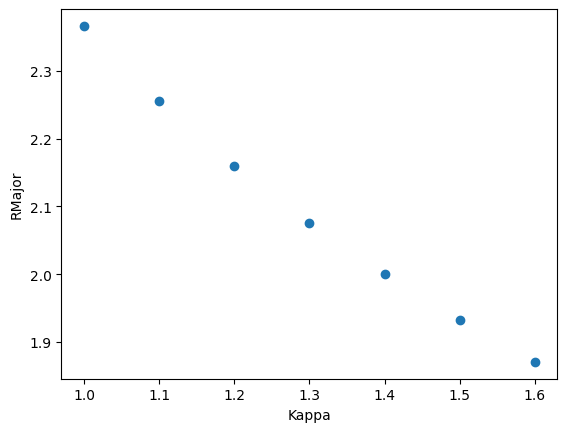

In [6]:

## Sample code for visualising a scan
plot_scan(scan_out, 'Kappa', 'RMajor')


In [7]:

## Sample code for exporting scan data to .csv for Mimer (https://assar.his.se/mimer/html/). Be careful with overwriting data!
write_csv(scan_out, filename = 'demo_output.csv')


In [ ]:

## Option to look at scan embedded in IPython, by typing e.g. "scan_out[3]", "scan_out[5]"
# embed()


Python 3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
Type 'copyright', 'credits' or 'license' for more information
IPython 8.12.3 -- An enhanced Interactive Python. Type '?' for help.




Out[1]: 1

Out[2]: 2





KeyboardInterrupt: Interrupted by user